# Datathon Fase 5 — Análise de Sentimento em Reclamações de Clientes

## Objetivo
Este projeto tem como objetivo aplicar técnicas de Processamento de Linguagem Natural (NLP) em um conjunto de reclamações de consumidores do setor financeiro, com foco em:

- realizar o pré-processamento dos textos;
- criar uma variável alvo de sentimento com classes positiva e negativa;
- treinar um modelo baseline de classificação textual e, em seguida, aplicar um modelo de Deep Learning para comparação e atendimento integral ao desafio;
- analisar as principais dores dos clientes por categoria de produto.

Além da etapa de modelagem, o projeto também busca gerar insights de negócio a partir das reclamações negativas, identificando os temas mais recorrentes em cada categoria de produto.


## 1. Preparação do ambiente

Nesta etapa, são instaladas e importadas as bibliotecas necessárias para o desenvolvimento do projeto.

Serão utilizadas bibliotecas para:

- manipulação de dados;
- pré-processamento textual;
- modelagem de machine learning;
- uso de modelo pré-treinado de sentimento;
- geração de gráficos e visualizações.

In [1]:
#!pip install gensim
#!pip install nltk
#!pip install scikit-learn
#!pip install kagglehub pandas

In [2]:
import os
import re
import string
import unicodedata
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
import kagglehub

from collections import Counter
from wordcloud import WordCloud

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from transformers import pipeline

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

## 2. Recursos auxiliares de NLP

O pacote NLTK necessita de arquivos adicionais para funcionar corretamente, como:

- tokenizadores;
- listas de stopwords.

Esses recursos são baixados a seguir para permitir o tratamento adequado dos textos.

In [3]:
nltk.download("punkt_tab")
nltk.download("stopwords")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## 3. Organização dos artefatos do projeto

Como algumas etapas podem demorar mais para processar, será criada uma pasta para armazenar os principais artefatos gerados ao longo do notebook.

Isso permite:

- evitar retrabalho;
- continuar o projeto em outro momento;
- reaproveitar bases tratadas, modelos e resultados analíticos.

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
PASTA_PROJETO = "/content/drive/MyDrive/artefatos_fase5"
os.makedirs(PASTA_PROJETO, exist_ok=True)

print("Pasta do projeto:", PASTA_PROJETO)

Pasta do projeto: /content/drive/MyDrive/artefatos_fase5


## 4. Funções de persistência

As funções abaixo serão usadas para salvar e carregar arquivos importantes do projeto, como:

- amostras tratadas;
- bases com sentimento;
- conjuntos de treino e teste;
- modelo treinado;
- vetorizador TF-IDF;
- tabelas de frequências.

Essa etapa é importante para tornar o pipeline mais eficiente e reprodutível.

In [6]:
def salvar_csv(df, nome_arquivo, pasta=PASTA_PROJETO):
    caminho = os.path.join(pasta, nome_arquivo)
    df.to_csv(caminho, index=False)
    print(f"Salvo: {caminho}")

def carregar_csv(nome_arquivo, pasta=PASTA_PROJETO):
    caminho = os.path.join(pasta, nome_arquivo)
    df = pd.read_csv(caminho)
    print(f"Carregado: {caminho}")
    return df

def salvar_objeto(obj, nome_arquivo, pasta=PASTA_PROJETO):
    caminho = os.path.join(pasta, nome_arquivo)
    joblib.dump(obj, caminho)
    print(f"Salvo: {caminho}")

def carregar_objeto(nome_arquivo, pasta=PASTA_PROJETO):
    caminho = os.path.join(pasta, nome_arquivo)
    obj = joblib.load(caminho)
    print(f"Carregado: {caminho}")
    return obj

## 5. Coleta dos dados

Nesta etapa, será realizado o download do dataset de reclamações de consumidores por meio do `kagglehub`.

A base escolhida contém narrativas textuais relacionadas a produtos financeiros, sendo apropriada para aplicações de NLP e análise de sentimento.

In [7]:
path = kagglehub.dataset_download("shashwatwork/consume-complaints-dataset-fo-nlp")
print("Dataset salvo em:", path)
print("Arquivos encontrados:", os.listdir(path))

100%|██████████| 19.8M/19.8M [00:00<00:00, 135MB/s]

Extracting files...


Dataset salvo em: /root/.cache/kagglehub/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/versions/1
Arquivos encontrados: ['complaints_processed.csv']


## 6. Leitura da base

Após o download, o arquivo CSV principal é carregado em um DataFrame do pandas.

A partir desse ponto, inicia-se a exploração e o tratamento dos dados.

In [8]:
df = pd.read_csv(os.path.join(path, "complaints_processed.csv"))
df.head()

,Unnamed: 0,product,narrative
0,0,credit_card,purchase order day shipping amount receive pro...
1,1,credit_card,forwarded message date tue subject please inve...
2,2,retail_banking,forwarded message cc sent friday pdt subject f...
3,3,credit_reporting,payment history missing credit report speciali...
4,4,credit_reporting,payment history missing credit report made mis...


## 7. Inspeção inicial dos dados

Antes de iniciar o tratamento textual, é importante compreender a estrutura da base.

Nesta etapa serão verificados:

- número de linhas e colunas;
- nomes das variáveis;
- tipos de dados;
- presença de valores ausentes.

Essa análise inicial orienta as decisões de limpeza e preparação da base.

In [9]:
print("Dimensão:", df.shape)
print("Colunas:", df.columns.tolist())
print("\nInformações gerais:")
df.info()

print("\nValores nulos:")
print(df.isnull().sum())

Dimensão: (162421, 3)
Colunas: ['Unnamed: 0', 'product', 'narrative']

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162421 entries, 0 to 162420
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   Unnamed: 0  162421 non-null  int64 
 1   product     162421 non-null  object
 2   narrative   162411 non-null  object
dtypes: int64(1), object(2)
memory usage: 3.7+ MB

Valores nulos:
Unnamed: 0     0
product        0
narrative     10
dtype: int64


## 8. Limpeza estrutural da base

Nesta etapa, são realizados ajustes iniciais na estrutura do dataset:

- remoção de colunas irrelevantes;
- exclusão de registros sem narrativa textual;
- embaralhamento dos dados;
- reorganização dos índices.

O embaralhamento é importante para reduzir possíveis vieses de ordenação da base original.

In [10]:
df = df.drop(columns=["Unnamed: 0"], errors="ignore") # tira a coluna de índice que veio na importação
df = df.dropna(subset=["narrative"]) # tira os dados nulos 162421-162411 = 10
df = shuffle(df, random_state=42) # embaralha e toda vez vai trazer o msm resultado
df = df.reset_index(drop=True) # novo indice depois de embaralhar

print("Nova dimensão:", df.shape)
df.head()

Nova dimensão: (162411, 2)


,product,narrative
0,mortgages_and_loans,called acima ask bill hold payment told date p...
1,credit_reporting,sent letter regarding inaccurate unknown thing...
2,mortgages_and_loans,purchased new vehicle alabama purchase price n...
3,debt_collection,contacted many time failed provide necessary d...
4,credit_card,cancellation trip emailed stating charge done ...


## 9. Definição de uma amostra de trabalho

Embora a base completa seja relevante, algumas etapas do pipeline podem ser custosas em termos de tempo e memória, especialmente aquelas que envolvem modelos pré-treinados.

Por isso, será utilizada inicialmente uma amostra de 20.000 registros para:

- validar o pipeline;
- reduzir custo computacional;
- facilitar experimentação e interpretação dos resultados.

In [11]:
df_sample = df.sample(50000, random_state=42).copy()
print("Dimensão da amostra:", df_sample.shape)
df_sample.head()

Dimensão da amostra: (50000, 2)


,product,narrative
114588,debt_collection,contacted account service requesting debt vali...
108963,credit_reporting,continuing respond updated account could verif...
104278,retail_banking,fiance initiated transfer app sunday received ...
53748,mortgages_and_loans,two degree overall navient incredibly difficul...
44721,credit_reporting,victim identity notified collection creditor s...


## 10. Salvamento da amostra inicial

A amostra bruta é salva para possibilitar reaproveitamento posterior, sem necessidade de repetir as etapas anteriores de leitura e filtragem da base completa.

In [12]:
salvar_csv(df_sample, "01_sample_bruta.csv")

Salvo: /content/drive/MyDrive/artefatos_fase5/01_sample_bruta.csv


## 11. Pré-processamento textual

Nesta etapa, será aplicada uma função de limpeza nos textos da coluna `narrative`.

As transformações realizadas incluem:

- conversão para letras minúsculas;
- remoção de acentos;
- remoção de números;
- remoção de pontuação;
- tokenização;
- remoção de stopwords;
- remoção de tokens muito curtos.

O objetivo é reduzir ruídos e padronizar os textos para as etapas seguintes de modelagem e análise.

In [13]:
stop_words = set(stopwords.words("english"))

def clean_text(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = unicodedata.normalize("NFKD", text).encode("ASCII", "ignore").decode("utf-8")
    text = re.sub(r"\d+", " ", text)
    text = text.translate(str.maketrans({p: " " for p in string.punctuation}))
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    tokens = [t for t in tokens if len(t) > 2]
    return " ".join(tokens)

## 12. Geração da coluna de texto tratado

A limpeza textual será aplicada à amostra selecionada, gerando uma nova coluna chamada `narrative_clean`.

Manteremos:

- a coluna original (`narrative`);
- a coluna tratada (`narrative_clean`).

Isso permite comparar o texto bruto com sua versão processada.

In [14]:
df_sample["narrative_clean"] = df_sample["narrative"].apply(clean_text)
df_sample[["narrative", "narrative_clean"]].head()

,narrative,narrative_clean
114588,contacted account service requesting debt vali...,contacted account service requesting debt vali...
108963,continuing respond updated account could verif...,continuing respond updated account could verif...
104278,fiance initiated transfer app sunday received ...,fiance initiated transfer app sunday received ...
53748,two degree overall navient incredibly difficul...,two degree overall navient incredibly difficul...
44721,victim identity notified collection creditor s...,victim identity notified collection creditor s...


## 13. Persistência da amostra tratada

Como o pré-processamento textual pode ser relativamente custoso, a amostra já tratada será salva.

Dessa forma, em execuções futuras, será possível retomar o projeto a partir dessa etapa.

In [15]:
salvar_csv(df_sample, "02_sample_tratada.csv")

Salvo: /content/drive/MyDrive/artefatos_fase5/02_sample_tratada.csv


## 14. Criação da variável alvo de sentimento

O dataset original não possui uma coluna explícita de sentimento.

Para atender ao desafio proposto, será utilizada uma abordagem de rotulagem automática com um modelo pré-treinado de análise de sentimento.

A ideia é gerar uma nova variável alvo com duas classes:

- `positive`
- `negative`

Essa estratégia permite transformar a base em um problema supervisionado de classificação.

In [16]:
sentiment_model = pipeline(
    "sentiment-analysis",
    model="distilbert/distilbert-base-uncased-finetuned-sst-2-english"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

## 15. Inferência de sentimento

Nesta etapa, o modelo pré-treinado é aplicado aos textos tratados da amostra.

O resultado bruto retornado pelo modelo é padronizado em uma nova coluna chamada `sentiment`, que será utilizada como variável alvo nos experimentos de classificação.

In [17]:
df_sample["sentiment_raw"] = df_sample["narrative_clean"].apply(
    lambda x: sentiment_model(x[:512])[0]["label"] if isinstance(x, str) and x.strip() else "NEGATIVE"
)

In [18]:
df_sample["sentiment"] = df_sample["sentiment_raw"].replace({
    "POSITIVE": "positive",
    "NEGATIVE": "negative"
})

In [19]:
df_sample[["narrative_clean", "sentiment_raw", "sentiment"]].head()

,narrative_clean,sentiment_raw,sentiment
114588,contacted account service requesting debt vali...,NEGATIVE,negative
108963,continuing respond updated account could verif...,NEGATIVE,negative
104278,fiance initiated transfer app sunday received ...,NEGATIVE,negative
53748,two degree overall navient incredibly difficul...,NEGATIVE,negative
44721,victim identity notified collection creditor s...,NEGATIVE,negative


## 16. Salvamento da base com sentimento

A base contendo os textos já tratados e a nova variável de sentimento será salva, pois esta é uma das etapas mais importantes e potencialmente mais demoradas do pipeline.

In [20]:
salvar_csv(df_sample, "03_sample_com_sentimento.csv")

Salvo: /content/drive/MyDrive/artefatos_fase5/03_sample_com_sentimento.csv


## 17. Distribuição da variável alvo

Após a criação da coluna de sentimento, é importante verificar como as classes ficaram distribuídas.

Essa análise permite identificar:

- possíveis desequilíbrios entre classes;
- tendências da base;
- impactos esperados na modelagem.

Como a base é formada por reclamações, é plausível que a classe negativa seja predominante.

In [21]:
print(df_sample["sentiment_raw"].value_counts())

sentiment_raw
NEGATIVE    49256
POSITIVE      744
Name: count, dtype: int64


In [22]:
print(df_sample["sentiment"].value_counts())

sentiment
negative    49256
positive      744
Name: count, dtype: int64


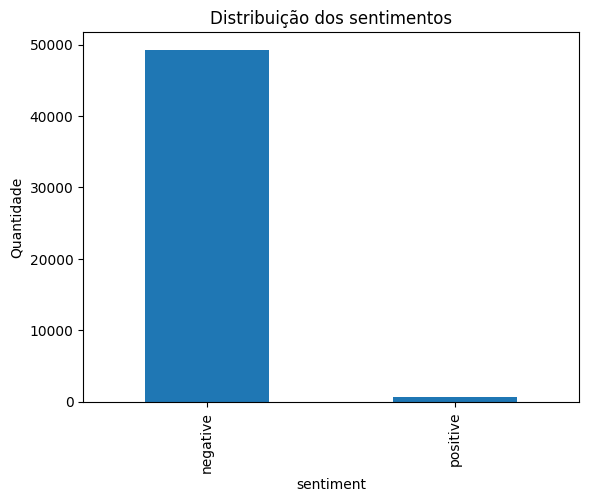

In [23]:
df_sample["sentiment"].value_counts().plot(kind="bar")
plt.title("Distribuição dos sentimentos")
plt.ylabel("Quantidade")
plt.show()

## 18. Separação entre variáveis preditoras e variável alvo

A partir deste ponto, definimos formalmente o problema de classificação:

- **X**: texto tratado da reclamação;
- **y**: sentimento inferido.

Essa separação é essencial para treinar e avaliar o modelo supervisionado.

Como a base é composta por reclamações de consumidores, observou-se forte predominância de sentimento negativo na rotulagem automática. Para viabilizar a etapa de classificação supervisionada, foi criada uma base balanceada entre as classes positiva e negativa.

In [24]:
positivos = df_sample[df_sample["sentiment"] == "positive"].copy()
negativos = df_sample[df_sample["sentiment"] == "negative"].sample(n=len(positivos), random_state=42)

df_balanceado = pd.concat([positivos, negativos], axis=0)
df_balanceado = shuffle(df_balanceado, random_state=42).reset_index(drop=True)

print(df_balanceado["sentiment"].value_counts())

sentiment
negative    744
positive    744
Name: count, dtype: int64


In [25]:
salvar_csv(df_balanceado, "03b_df_balanceado.csv")

Salvo: /content/drive/MyDrive/artefatos_fase5/03b_df_balanceado.csv


In [26]:
X = df_balanceado["narrative_clean"]
y = df_balanceado["sentiment"]

## 19. Separação entre treino e teste

Para avaliar o desempenho do modelo de forma adequada, a base será dividida em dois conjuntos:

- treino;
- teste.

A estratificação será mantida para preservar, na medida do possível, a proporção entre as classes em ambos os conjuntos.

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_train.shape, y_train.shape)
print("Teste:", X_test.shape, y_test.shape)

Treino: (1190,) (1190,)
Teste: (298,) (298,)


In [28]:
pd.DataFrame({"text": X_train}).to_csv(os.path.join(PASTA_PROJETO, "04_X_train.csv"), index=False)
pd.DataFrame({"text": X_test}).to_csv(os.path.join(PASTA_PROJETO, "05_X_test.csv"), index=False)
pd.DataFrame({"target": y_train}).to_csv(os.path.join(PASTA_PROJETO, "06_y_train.csv"), index=False)
pd.DataFrame({"target": y_test}).to_csv(os.path.join(PASTA_PROJETO, "07_y_test.csv"), index=False)

print("Conjuntos salvos.")

Conjuntos salvos.


## 20. Transformação de texto em representação numérica

Modelos tradicionais de machine learning não trabalham diretamente com texto bruto.

Por isso, será utilizada a técnica **TF-IDF** para converter cada narrativa em um vetor numérico, preservando a importância relativa das palavras no corpus.

Essa etapa constitui a representação matemática dos textos para o baseline.

Este modelo representa um baseline de machine learning tradicional, utilizado como referência inicial de desempenho.

In [29]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF treino:", X_train_tfidf.shape)
print("TF-IDF teste:", X_test_tfidf.shape)

TF-IDF treino: (1190, 4569)
TF-IDF teste: (298, 4569)


## 21. Persistência do vetorizador

O vetorizador TF-IDF também será salvo, pois ele faz parte do pipeline de transformação dos dados e será necessário para reproduzir resultados ou aplicar o modelo futuramente.

In [30]:
salvar_objeto(vectorizer, "08_tfidf_vectorizer.pkl")

Salvo: /content/drive/MyDrive/artefatos_fase5/08_tfidf_vectorizer.pkl


## 22. Modelo baseline

Como primeira abordagem de classificação, será treinado um modelo baseline com:

- vetorização TF-IDF;
- regressão logística.

Foi utilizada a opção `class_weight="balanced"` para reduzir o impacto de possíveis desequilíbrios entre as classes, dando maior atenção à classe minoritária.

In [31]:
baseline_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

baseline_model.fit(X_train_tfidf, y_train)
y_pred_baseline = baseline_model.predict(X_test_tfidf)
y_prob_baseline = baseline_model.predict_proba(X_test_tfidf)

## 23. Persistência do modelo baseline

Após o treinamento, o modelo baseline será salvo para possibilitar:

- reutilização futura;
- comparação com outras abordagens;
- continuidade do projeto sem necessidade de novo treinamento.

In [32]:
salvar_objeto(baseline_model, "09_baseline_model.pkl")

Salvo: /content/drive/MyDrive/artefatos_fase5/09_baseline_model.pkl


## 24. Avaliação do modelo baseline

O desempenho do baseline será avaliado com métricas clássicas de classificação, incluindo:

- Accuracy;
- F1-score;
- relatório de classificação;
- matriz de confusão.

Essa etapa permite verificar não apenas a taxa geral de acerto, mas também o comportamento do modelo em cada classe.

- a accuracy não deve ser analisada sozinha
- como a base é pequena, as métricas podem oscilar bastante

In [33]:
print("Accuracy:", accuracy_score(y_test, y_pred_baseline))
print("F1 (negative):", f1_score(y_test, y_pred_baseline, pos_label="negative"))
print("F1 macro:", f1_score(y_test, y_pred_baseline, average="macro"))
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_baseline))

Accuracy: 0.8087248322147651
F1 (negative): 0.8155339805825242
F1 macro: 0.8084638544027604

Relatório de classificação:
              precision    recall  f1-score   support

    negative       0.79      0.85      0.82       149
    positive       0.83      0.77      0.80       149

    accuracy                           0.81       298
   macro avg       0.81      0.81      0.81       298
weighted avg       0.81      0.81      0.81       298



In [34]:
resultado_teste = pd.DataFrame({
    "texto": X_test.reset_index(drop=True),
    "real": y_test.reset_index(drop=True),
    "predito": pd.Series(y_pred_baseline).reset_index(drop=True),
    "prob_negative": y_prob_baseline[:, list(baseline_model.classes_).index("negative")],
    "prob_positive": y_prob_baseline[:, list(baseline_model.classes_).index("positive")]
})

salvar_csv(resultado_teste, "13_resultado_teste_baseline.csv")

Salvo: /content/drive/MyDrive/artefatos_fase5/13_resultado_teste_baseline.csv


## 24B. Modelo de Deep Learning

Para atender integralmente ao desafio, será treinado um modelo de Deep Learning para classificação de sentimento.

A abordagem escolhida utiliza uma rede neural com:
- tokenização dos textos;
- padding das sequências;
- camada de embedding;
- camada LSTM;
- camada densa de saída.

Esse modelo será comparado ao baseline tradicional construído anteriormente.

In [35]:
# codificar y em números
label_encoder = LabelEncoder()
y_train_dl = label_encoder.fit_transform(y_train)
y_test_dl = label_encoder.transform(y_test)

# tokenização
max_words = 20000
max_len = 200

tokenizer_dl = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer_dl.fit_on_texts(X_train)

X_train_seq = tokenizer_dl.texts_to_sequences(X_train)
X_test_seq = tokenizer_dl.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

print("X_train_pad:", X_train_pad.shape)
print("X_test_pad:", X_test_pad.shape)

X_train_pad: (1190, 200)
X_test_pad: (298, 200)


In [36]:
model_dl = Sequential([
    Embedding(input_dim=max_words, output_dim=256, input_length=max_len),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model_dl.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model_dl.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [37]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True
)

history = model_dl.fit(
    X_train_pad,
    y_train_dl,
    validation_split=0.2,
    epochs=20,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 48s 693ms/step - accuracy: 0.5116 - loss: 0.6953 - val_accuracy: 0.5294 - val_loss: 0.6909
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 78s 638ms/step - accuracy: 0.5578 - loss: 0.7093 - val_accuracy: 0.5000 - val_loss: 0.6933
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 688ms/step - accuracy: 0.4853 - loss: 0.6920 - val_accuracy: 0.5294 - val_loss: 0.6863
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 38s 637ms/step - accuracy: 0.5431 - loss: 0.6778 - val_accuracy: 0.5294 - val_loss: 0.6924
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 41s 685ms/step - accuracy: 0.5284 - loss: 0.6747 - val_accuracy: 0.5294 - val_loss: 0.6809
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 39s 654ms/step - accuracy: 0.5525 - loss: 0.6699 - val_accuracy: 0.5294 - val_loss: 0.6896
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 662ms/step - accuracy: 0.5420 - loss: 0.6693 - val_accuracy: 0.5000 - val_loss: 1.0093
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 40s 667ms/step - accuracy: 0.5420 - loss: 0.6786 - val_accu

In [38]:
y_prob_dl = model_dl.predict(X_test_pad)
y_pred_dl = (y_prob_dl > 0.5).astype("int32").flatten()

print("Accuracy DL:", accuracy_score(y_test_dl, y_pred_dl))
print("F1 macro DL:", f1_score(y_test_dl, y_pred_dl, average="macro"))
print("\nRelatório DL:")
print(classification_report(y_test_dl, y_pred_dl, target_names=label_encoder.classes_))

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 139ms/step
Accuracy DL: 0.5268456375838926
F1 macro DL: 0.40004283572499466

Relatório DL:
              precision    recall  f1-score   support

    negative       0.83      0.07      0.12       149
    positive       0.51      0.99      0.68       149

    accuracy                           0.53       298
   macro avg       0.67      0.53      0.40       298
weighted avg       0.67      0.53      0.40       298



Embora o modelo de Deep Learning atenda ao requisito do desafio, seu desempenho foi inferior ao baseline nesta configuração. Esse resultado pode estar relacionado ao tamanho relativamente reduzido da base balanceada, à simplicidade da arquitetura utilizada e ao fato de modelos neurais geralmente demandarem maior volume de dados para melhor generalização.

## 25. Matriz de confusão

A matriz de confusão ajuda a visualizar:

- quantos exemplos foram corretamente classificados;
- onde ocorreram os erros;
- se o modelo está favorecendo uma classe específica.

Essa análise é especialmente relevante em bases desbalanceadas.

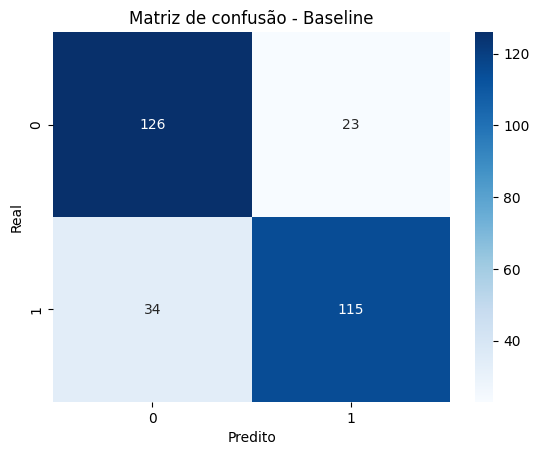

In [39]:
cm = confusion_matrix(y_test, y_pred_baseline)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusão - Baseline")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

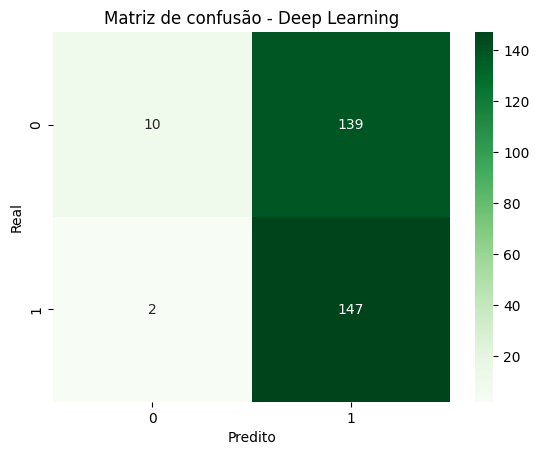

Salvo: /content/drive/MyDrive/artefatos_fase5/14_tokenizer_dl.pkl
Salvo: /content/drive/MyDrive/artefatos_fase5/15_resultado_teste_dl.csv


In [40]:
cm_dl = confusion_matrix(y_test_dl, y_pred_dl)
sns.heatmap(cm_dl, annot=True, fmt="d", cmap="Greens")
plt.title("Matriz de confusão - Deep Learning")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

salvar_objeto(tokenizer_dl, "14_tokenizer_dl.pkl")

resultado_teste_dl = pd.DataFrame({
    "texto": X_test.reset_index(drop=True),
    "real": y_test.reset_index(drop=True),
    "predito_dl": label_encoder.inverse_transform(y_pred_dl),
    "prob_dl": y_prob_dl.flatten()
})

salvar_csv(resultado_teste_dl, "15_resultado_teste_dl.csv")

## 26. Foco analítico nas reclamações negativas

Além da modelagem, o desafio propõe investigar as principais dores dos clientes.

Por isso, a partir deste ponto, a análise será concentrada nas reclamações classificadas como negativas, buscando identificar:

- categorias com maior volume de insatisfação;
- palavras mais frequentes;
- temas recorrentes por produto.

In [41]:
negative_df = df_sample[df_sample["sentiment"] == "negative"].copy()
print("Dimensão de negative_df:", negative_df.shape)
negative_df.head()

Dimensão de negative_df: (49256, 5)


,product,narrative,narrative_clean,sentiment_raw,sentiment
114588,debt_collection,contacted account service requesting debt vali...,contacted account service requesting debt vali...,NEGATIVE,negative
108963,credit_reporting,continuing respond updated account could verif...,continuing respond updated account could verif...,NEGATIVE,negative
104278,retail_banking,fiance initiated transfer app sunday received ...,fiance initiated transfer app sunday received ...,NEGATIVE,negative
53748,mortgages_and_loans,two degree overall navient incredibly difficul...,two degree overall navient incredibly difficul...,NEGATIVE,negative
44721,credit_reporting,victim identity notified collection creditor s...,victim identity notified collection creditor s...,NEGATIVE,negative


## 27. Persistência da base negativa

A base filtrada de reclamações negativas será salva, pois ela servirá de base para as análises descritivas e visuais da etapa de negócio.

In [42]:
salvar_csv(negative_df, "10_negative_df.csv")

Salvo: /content/drive/MyDrive/artefatos_fase5/10_negative_df.csv


## 28. Categorias com maior volume de reclamações negativas

Neste gráfico, observamos quais categorias de produtos concentram maior quantidade de reclamações negativas.

Essa visualização permite direcionar a análise para os produtos com maior potencial de insatisfação do cliente.

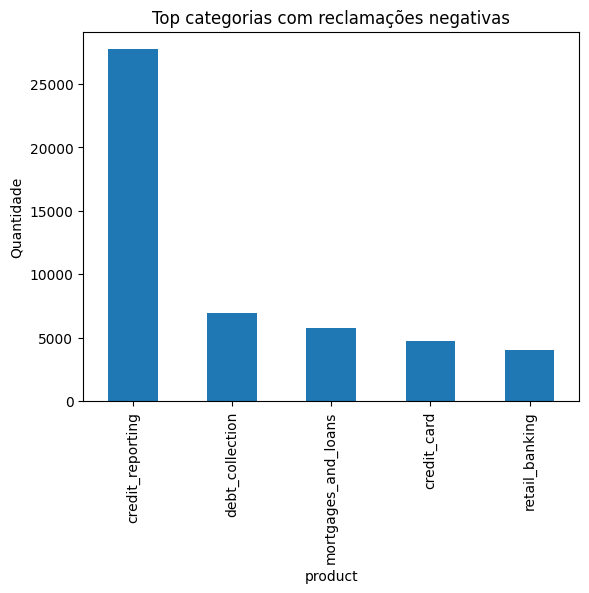

In [43]:
negative_df["product"].value_counts().head(10).plot(kind="bar")
plt.title("Top categorias com reclamações negativas")
plt.ylabel("Quantidade")
plt.show()

## 29. Termos mais frequentes nas reclamações negativas

A seguir, são identificadas as palavras mais frequentes nas reclamações negativas da amostra.

Essa análise ajuda a revelar temas recorrentes, como:

- problemas com crédito;
- questões ligadas a conta;
- pagamentos;
- dívidas;
- cartão de crédito;
- disputas e cobranças.

In [44]:
all_words = " ".join(negative_df["narrative_clean"])
word_freq = Counter(all_words.split())

top_words_df = pd.DataFrame(word_freq.most_common(20), columns=["word", "freq"])
top_words_df

,word,freq
0,account,96592
1,credit,96463
2,report,53844
3,information,44210
4,payment,38360
5,reporting,29066
6,time,25227
7,company,24565
8,would,24073
9,day,23337


In [45]:
salvar_csv(top_words_df, "11_top_words_negative.csv")

Salvo: /content/drive/MyDrive/artefatos_fase5/11_top_words_negative.csv


## 30. Nuvem de palavras das reclamações negativas

A nuvem de palavras oferece uma representação visual dos principais termos presentes nas reclamações negativas.

Quanto maior a palavra na visualização, maior sua frequência no conjunto analisado.

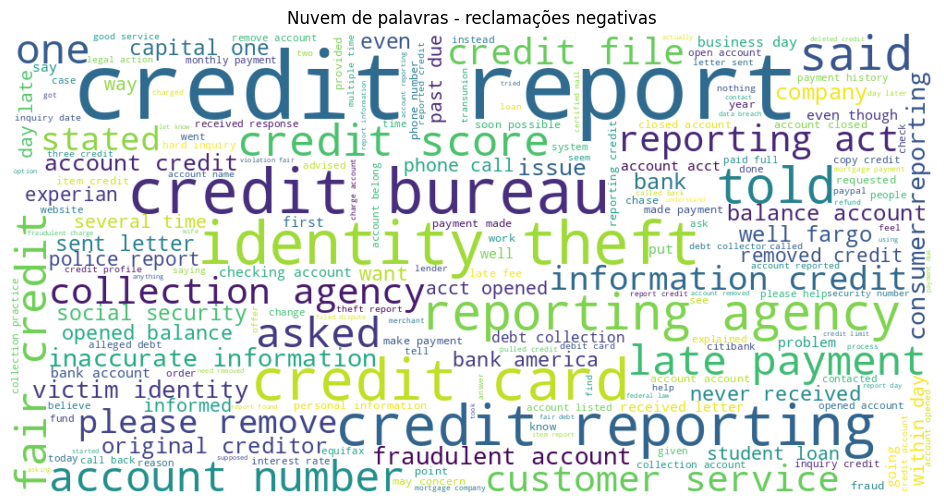

In [46]:
wordcloud = WordCloud(width=1000, height=500, background_color="white").generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Nuvem de palavras - reclamações negativas")
plt.show()

## 31. Análise textual por categoria de produto

Para aprofundar a análise das dores dos clientes, serão examinados os três produtos com maior volume de reclamações negativas.

Para cada produto, serão levantadas as palavras mais frequentes, permitindo identificar padrões específicos de insatisfação.

In [47]:
freq_por_produto = {}

for prod in negative_df["product"].value_counts().head(3).index:
    texto = " ".join(negative_df[negative_df["product"] == prod]["narrative_clean"])
    freq = Counter(texto.split()).most_common(10)
    freq_por_produto[prod] = freq

    print(f"\nProduto: {prod}")
    print(freq)


Produto: credit_reporting
[('credit', 68406), ('account', 57812), ('report', 43878), ('information', 33284), ('reporting', 24783), ('consumer', 15225), ('payment', 13695), ('dispute', 13179), ('bureau', 12043), ('letter', 11980)]

Produto: debt_collection
[('debt', 12705), ('credit', 11926), ('account', 10442), ('collection', 6576), ('report', 6349), ('company', 5935), ('information', 4793), ('letter', 3849), ('payment', 3656), ('received', 3634)]

Produto: mortgages_and_loans
[('payment', 14485), ('loan', 13670), ('mortgage', 8480), ('would', 6998), ('account', 5956), ('time', 5700), ('told', 5047), ('credit', 4797), ('company', 4579), ('received', 4494)]


## 32. Persistência das frequências por produto

Como essa tabela resume um resultado analítico importante para o relatório e para a apresentação, ela será salva para reaproveitamento posterior.

Isso evita recalcular manualmente as frequências em execuções futuras.

In [48]:
linhas_freq_produto = []

for prod, lista_freq in freq_por_produto.items():
    for palavra, frequencia in lista_freq:
        linhas_freq_produto.append({
            "product": prod,
            "word": palavra,
            "freq": frequencia
        })

freq_produto_df = pd.DataFrame(linhas_freq_produto)
freq_produto_df

,product,word,freq
0,credit_reporting,credit,68406
1,credit_reporting,account,57812
2,credit_reporting,report,43878
3,credit_reporting,information,33284
4,credit_reporting,reporting,24783
5,credit_reporting,consumer,15225
6,credit_reporting,payment,13695
7,credit_reporting,dispute,13179
8,credit_reporting,bureau,12043
9,credit_reporting,letter,11980


In [49]:
salvar_csv(freq_produto_df, "12_freq_por_produto_top3.csv")

Salvo: /content/drive/MyDrive/artefatos_fase5/12_freq_por_produto_top3.csv


## 33. Visualização comparativa das dores por produto

Os gráficos a seguir permitem comparar, de forma mais clara, os termos predominantes em cada uma das principais categorias com reclamações negativas.

Essa etapa aproxima a análise de uma perspectiva de negócio, ao destacar padrões específicos em cada produto financeiro.

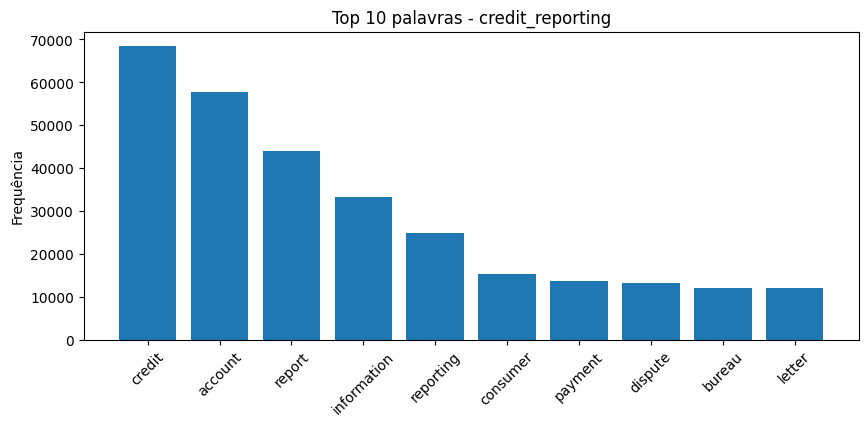

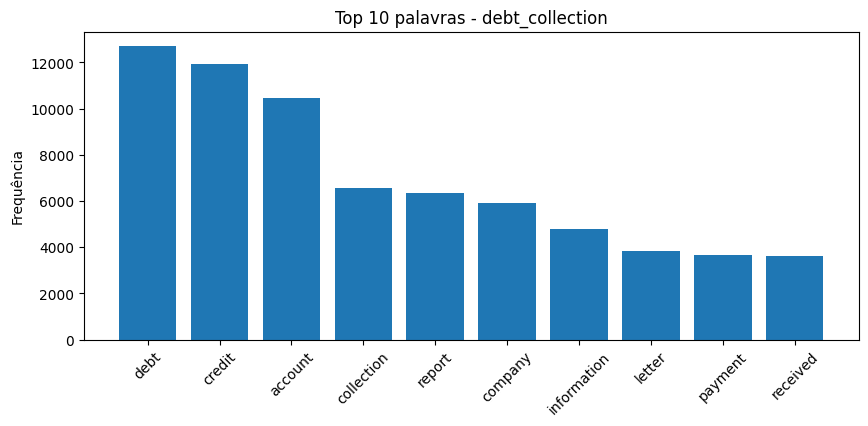

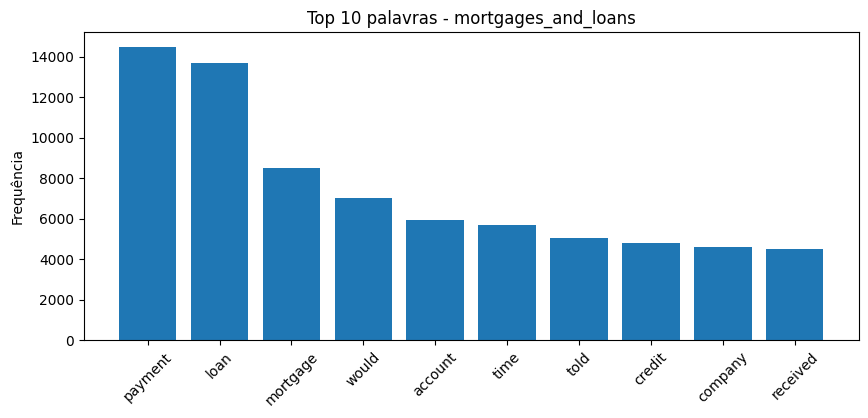

In [50]:
for prod in freq_produto_df["product"].unique():
    temp = freq_produto_df[freq_produto_df["product"] == prod]

    plt.figure(figsize=(10, 4))
    plt.bar(temp["word"], temp["freq"])
    plt.title(f"Top 10 palavras - {prod}")
    plt.xticks(rotation=45)
    plt.ylabel("Frequência")
    plt.show()

A análise das palavras mais frequentes por categoria de produto mostrou padrões distintos de insatisfação. Em credit_reporting, destacam-se termos relacionados a crédito, conta, relatório, informação, disputa e bureau, indicando problemas com registros e dados de crédito. Em debt_collection, predominam palavras como dívida, cobrança, conta, empresa, carta e pagamento, sugerindo foco em processos de cobrança e comunicação com empresas cobradoras. Já em mortgages_and_loans, os termos mais frequentes envolvem pagamento, empréstimo, hipoteca, conta e crédito, apontando dificuldades associadas a financiamentos, parcelas e atendimento.

## 34. Verificação dos artefatos gerados

Ao final do pipeline, listamos os arquivos salvos no projeto.

Esses artefatos representam as etapas mais importantes já processadas, permitindo que o trabalho seja retomado rapidamente em outro momento.

In [51]:
arquivos_salvos = sorted(os.listdir(PASTA_PROJETO))
print("Arquivos salvos no projeto:")
for arq in arquivos_salvos:
    print(arq)

Arquivos salvos no projeto:
01_sample_bruta.csv
02_sample_tratada.csv
03_sample_com_sentimento.csv
03b_df_balanceado.csv
04_X_train.csv
05_X_test.csv
06_y_train.csv
07_y_test.csv
08_tfidf_vectorizer.pkl
09_baseline_model.pkl
10_negative_df.csv
11_top_words_negative.csv
12_freq_por_produto_top3.csv
13_resultado_teste_baseline.csv
14_tokenizer_dl.pkl
15_resultado_teste_dl.csv


## 35. Continuidade do projeto

Caso o notebook seja fechado ou a sessão seja encerrada, os artefatos salvos podem ser recarregados para continuidade do trabalho, evitando reprocessamento desnecessário.

In [52]:
df_sample = carregar_csv("03_sample_com_sentimento.csv")
negative_df = carregar_csv("10_negative_df.csv")
top_words_df = carregar_csv("11_top_words_negative.csv")
freq_produto_df = carregar_csv("12_freq_por_produto_top3.csv")

vectorizer = carregar_objeto("08_tfidf_vectorizer.pkl")
baseline_model = carregar_objeto("09_baseline_model.pkl")

Carregado: /content/drive/MyDrive/artefatos_fase5/03_sample_com_sentimento.csv
Carregado: /content/drive/MyDrive/artefatos_fase5/10_negative_df.csv
Carregado: /content/drive/MyDrive/artefatos_fase5/11_top_words_negative.csv
Carregado: /content/drive/MyDrive/artefatos_fase5/12_freq_por_produto_top3.csv
Carregado: /content/drive/MyDrive/artefatos_fase5/08_tfidf_vectorizer.pkl
Carregado: /content/drive/MyDrive/artefatos_fase5/09_baseline_model.pkl


# Conclusão

Este projeto apresentou um pipeline de NLP aplicado a reclamações de consumidores do setor financeiro.

As principais etapas desenvolvidas foram:
- leitura e limpeza estrutural da base;
- pré-processamento textual das narrativas;
- criação de uma variável alvo de sentimento por meio de modelo pré-treinado;
- balanceamento da base para viabilizar a modelagem supervisionada;
- treinamento de um baseline com TF-IDF e regressão logística;
- treinamento de um modelo de Deep Learning com Embedding + LSTM;
- avaliação comparativa dos modelos;
- análise das principais dores dos clientes por categoria de produto.

Os resultados mostraram que o baseline apresentou desempenho superior ao modelo LSTM nesta configuração, enquanto a análise textual das reclamações negativas permitiu identificar temas recorrentes como problemas com crédito, contas, pagamentos, dívidas e disputas em produtos específicos.